In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('F','AVGO'), 
         ('F','JPM'), 
         ('F','XOM'), 
         ('STX','AVGO'), 
         ('STX', 'JPM'),
         ('STX', 'XOM'), 
         ('MO','AVGO'), 
         ('MO', 'JPM'), 
         ('MO','XOM')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

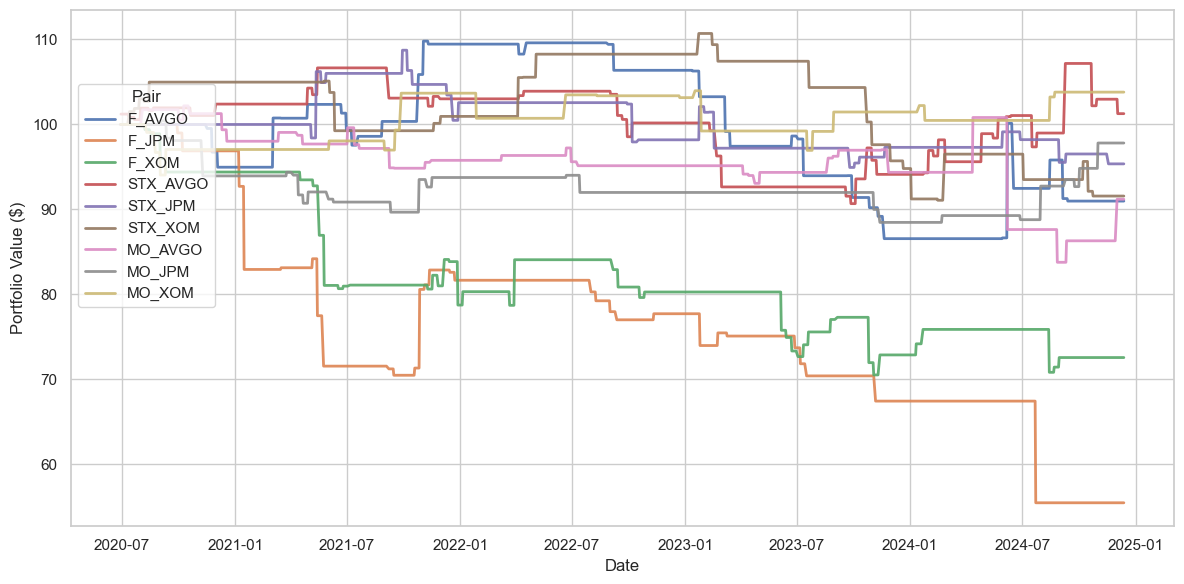

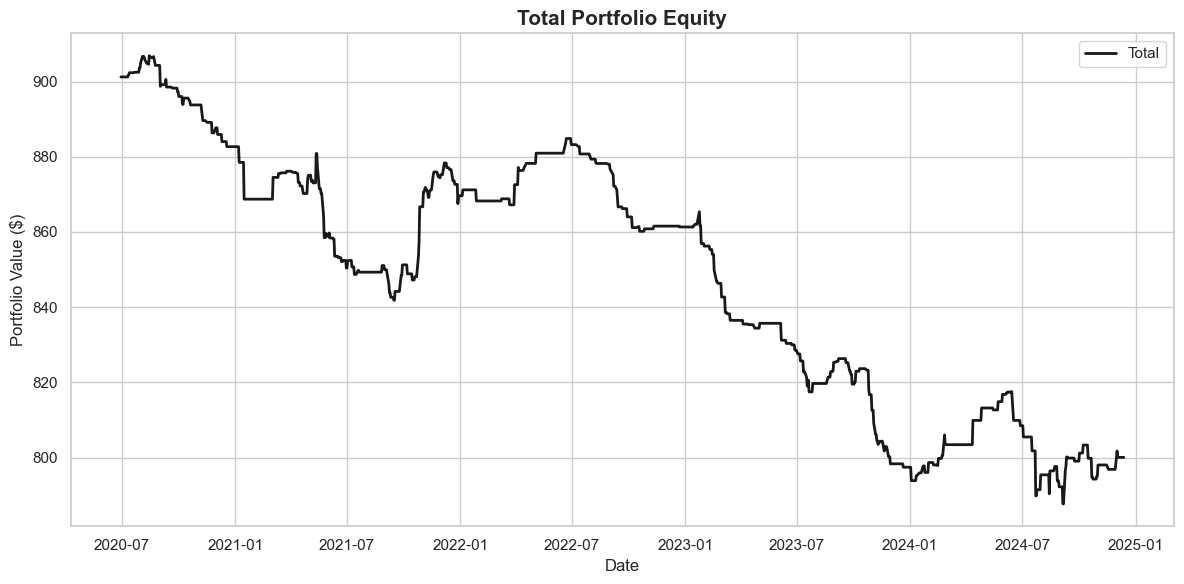

Summary
F_AVGO: Final Value = $90.98, Total Return = -9.02%, Trades = 36
F_JPM: Final Value = $55.48, Total Return = -44.52%, Trades = 29
F_XOM: Final Value = $72.57, Total Return = -27.43%, Trades = 40
STX_AVGO: Final Value = $101.27, Total Return = 0.05%, Trades = 47
STX_JPM: Final Value = $95.36, Total Return = -4.64%, Trades = 26
STX_XOM: Final Value = $91.58, Total Return = -8.42%, Trades = 28
MO_AVGO: Final Value = $91.20, Total Return = -8.80%, Trades = 34
MO_JPM: Final Value = $97.82, Total Return = -2.18%, Trades = 26
MO_XOM: Final Value = $103.81, Total Return = 3.81%, Trades = 21

Total Portfolio Performance
Initial Portfolio Value: $901.22
Final Portfolio Value:   $800.07
Total Return:            -11.22%

Sharpe Ratios
F_AVGO: Sharpe Ratio = -0.14
F_JPM: Sharpe Ratio = -0.90
F_XOM: Sharpe Ratio = -0.72
STX_AVGO: Sharpe Ratio = 0.04
STX_JPM: Sharpe Ratio = -0.14
STX_XOM: Sharpe Ratio = -0.28
MO_AVGO: Sharpe Ratio = -0.20
MO_JPM: Sharpe Ratio = -0.08
MO_XOM: Sharpe Ratio = 0.

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)